# Confronto: diffusore from-scratch (04b) vs diffusore fine-tuned (03b)

Notebook di sola analisi: legge esclusivamente gli artefatti gia' prodotti da

- `03b_Finetuning_StableDiffusion2.1_filtered.ipynb` -> Stable Diffusion 2.1 **fine-tuned** sulle mammografie RSNA (100 inference step, filtro adattivo, 1361 immagini/classe);
- `04b_LDM_extra1361.ipynb` -> Latent Diffusion Model Keras addestrato **from scratch** (VAE + UNet, 80000 step, filtro adattivo, 1361 immagini per la sola classe positiva).

Nessuna immagine viene generata qui e non serve la GPU. I due esperimenti non sono perfettamente simmetrici: il modello from-scratch ha prodotto finora soltanto la classe positiva (tumorale), mentre il fine-tuned ha prodotto entrambe le classi. Dove il confronto a tre vie (reali / from-scratch / fine-tuned) non e' possibile, il notebook lo segnala invece di nasconderlo.

Contenuto:

1. griglia reali vs from-scratch vs fine-tuned (classe positiva);
2. griglia reali vs fine-tuned (classe negativa, from-scratch non disponibile);
3. metriche finali sul test set (FID, Inception Score, PRDC);
4. effetto del filtro adattivo sul validation set (raw vs filtrate);
5. traiettoria di selezione del checkpoint durante il training;
6. costo energetico e CO2 stimati delle due pipeline;
7. tabella di riepilogo.


## 1. Percorsi progetto e sorgenti dei due esperimenti

In [22]:
from pathlib import Path
import sys

PROJECT_NAME = "MammoDiffusion"
RESULTS_STAGE_NAME = "10_confronto_fromscratch_vs_finetuned"

# Se serve su Colab/Drive:
# PROJECT_ROOT_OVERRIDE = Path("/content/drive/MyDrive/MammoDiffusion")
PROJECT_ROOT_OVERRIDE = None


def find_project_root(project_name=PROJECT_NAME, override=PROJECT_ROOT_OVERRIDE):
    if override is not None:
        root = Path(override).expanduser().resolve()
        if not root.exists():
            raise FileNotFoundError(f"PROJECT_ROOT_OVERRIDE non esiste: {root}")
        return root

    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if candidate.name == project_name:
            return candidate
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate

    for candidate in [
        cwd / project_name,
        Path("/content") / project_name,
        Path("/content/drive/MyDrive") / project_name,
        Path.home() / project_name,
    ]:
        if candidate.exists():
            return candidate.resolve()

    raise FileNotFoundError(
        "Non riesco a trovare la root MammoDiffusion. "
        "Esegui il notebook dalla repo o imposta PROJECT_ROOT_OVERRIDE."
    )


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
DATA_PROCESSED_DIR = DATA_DIR / "processed"
SYNTHETIC_DIR = DATA_DIR / "synthetic"

# Risultati gia' prodotti dai due notebook confrontati (sola lettura)
RESULTS_FT_DIR = PROJECT_ROOT / "results" / "03b_finetuning_filtered"
RESULTS_FS_DIR = PROJECT_ROOT / "results" / "04b_ldm_keras_v2_extra1361"

# Output di questo notebook
RESULTS_DIR = PROJECT_ROOT / "results" / RESULTS_STAGE_NAME
RESULTS_PLOTS_DIR = RESULTS_DIR / "plots"
RESULTS_METRICS_DIR = RESULTS_DIR / "metrics"
for directory in [RESULTS_DIR, RESULTS_PLOTS_DIR, RESULTS_METRICS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT     :", PROJECT_ROOT)
print("RESULTS_FT_DIR   :", RESULTS_FT_DIR, "(03b, fine-tuned)")
print("RESULTS_FS_DIR   :", RESULTS_FS_DIR, "(04b, from scratch)")
print("RESULTS_DIR      :", RESULTS_DIR)


PROJECT_ROOT     : /Users/alexandro/Desktop/MammoDiffusion
RESULTS_FT_DIR   : /Users/alexandro/Desktop/MammoDiffusion/results/03b_finetuning_filtered (03b, fine-tuned)
RESULTS_FS_DIR   : /Users/alexandro/Desktop/MammoDiffusion/results/04b_ldm_keras_v2_extra1361 (04b, from scratch)
RESULTS_DIR      : /Users/alexandro/Desktop/MammoDiffusion/results/10_confronto_fromscratch_vs_finetuned


## 2. Immagini reali e sintetiche disponibili

Le immagini reali di confronto sono quelle del **test set** (mai usate per scegliere checkpoint o calibrare i filtri in nessuno dei due notebook). Le sintetiche sono le versioni gia' **filtrate** (1361 immagini/classe) prodotte dai due notebook e salvate in `data/synthetic/`:

- `data/synthetic/fine_tuned/{positive,negative}` -> 03b;
- `data/synthetic/fromscratch/positive` -> 04b (la classe negativa non e' ancora stata generata).

In [23]:
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg"}


def count_images(directory):
    directory = Path(directory)
    if not directory.is_dir():
        return 0
    return sum(1 for p in directory.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS)


REAL_DIRS = {
    "positive": DATA_PROCESSED_DIR / "test" / "1",
    "negative": DATA_PROCESSED_DIR / "test" / "0",
}

# Fine-tuned (03b): Stable Diffusion 2.1, entrambe le classi disponibili.
FINETUNED_DIRS = {
    "positive": SYNTHETIC_DIR / "fine_tuned" / "positive",
    "negative": SYNTHETIC_DIR / "fine_tuned" / "negative",
}

# From scratch (04b): LDM Keras, solo la classe positiva generata finora.
FROMSCRATCH_DIRS = {
    "positive": SYNTHETIC_DIR / "fromscratch" / "positive",
}

print("Reali (test):")
for label, directory in REAL_DIRS.items():
    print(f"  {label:9s}: {count_images(directory):4d}  ({directory})")

print("\nFine-tuned (03b, filtrate):")
for label, directory in FINETUNED_DIRS.items():
    print(f"  {label:9s}: {count_images(directory):4d}  ({directory})")

print("\nFrom scratch (04b, filtrate):")
for label, directory in FROMSCRATCH_DIRS.items():
    print(f"  {label:9s}: {count_images(directory):4d}  ({directory})")
print("  negative : non disponibile, il modello from-scratch ha generato solo la classe positiva")


Reali (test):
  positive :   73  (/Users/alexandro/Desktop/MammoDiffusion/data/processed/test/1)
  negative :  365  (/Users/alexandro/Desktop/MammoDiffusion/data/processed/test/0)

Fine-tuned (03b, filtrate):
  positive : 1361  (/Users/alexandro/Desktop/MammoDiffusion/data/synthetic/fine_tuned/positive)
  negative : 1361  (/Users/alexandro/Desktop/MammoDiffusion/data/synthetic/fine_tuned/negative)

From scratch (04b, filtrate):
  positive : 1361  (/Users/alexandro/Desktop/MammoDiffusion/data/synthetic/fromscratch/positive)
  negative : non disponibile, il modello from-scratch ha generato solo la classe positiva


## 3. Griglia principale: reali vs from-scratch vs fine-tuned (classe positiva)

Prime 5 immagini di ciascuna cartella, in ordine alfabetico di nome file (nessun campionamento casuale). E' la classe su cui entrambe le pipeline hanno generato immagini, quindi il confronto a tre vie e' possibile solo qui.

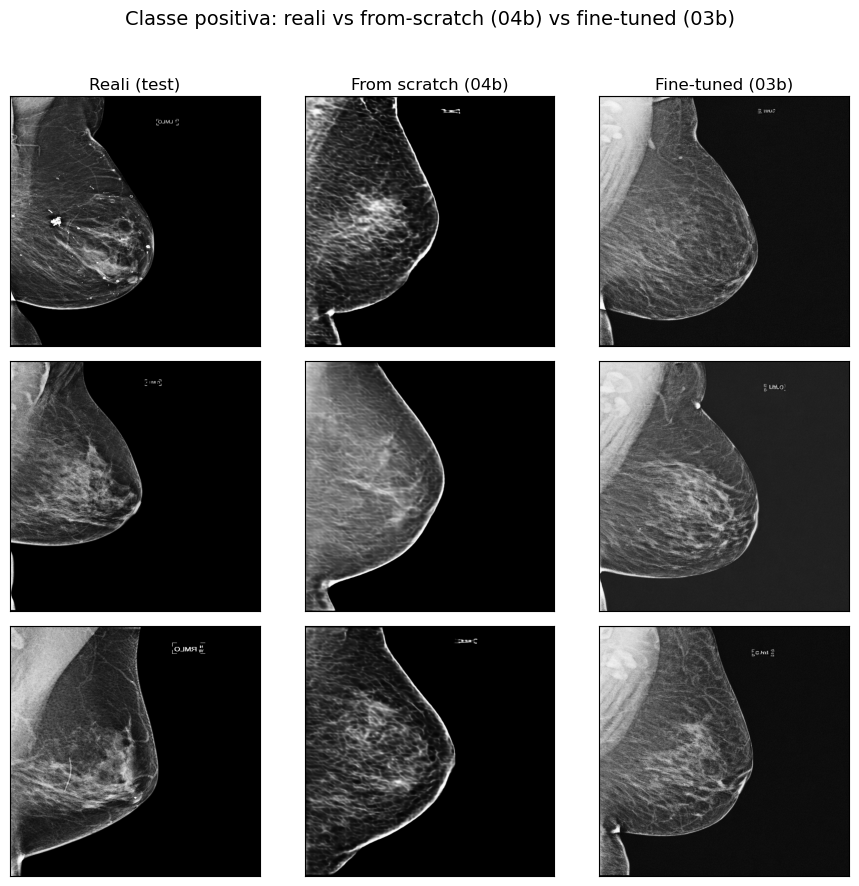

Salvato: /Users/alexandro/Desktop/MammoDiffusion/results/10_confronto_fromscratch_vs_finetuned/plots/grid_real_vs_fromscratch_vs_finetuned_positive.png


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image as PILImage

N_SAMPLES = 3


def first_image_paths(directory, n_samples):
    return sorted(Path(directory).glob("*.png"))[:n_samples]


positive_groups = {
    "Reali (test)": first_image_paths(REAL_DIRS["positive"], N_SAMPLES),
    "From scratch (04b)": first_image_paths(FROMSCRATCH_DIRS["positive"], N_SAMPLES),
    "Fine-tuned (03b)": first_image_paths(FINETUNED_DIRS["positive"], N_SAMPLES),
}

fig, axes = plt.subplots(N_SAMPLES, 3, figsize=(9, 3 * N_SAMPLES))
for col, (group_name, paths) in enumerate(positive_groups.items()):
    for row, path in enumerate(paths):
        with PILImage.open(path) as image:
            axes[row, col].imshow(np.asarray(image.convert("L")), cmap="gray", vmin=0, vmax=255)
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])
    axes[0, col].set_title(group_name, fontsize=12)

fig.suptitle("Classe positiva: reali vs from-scratch (04b) vs fine-tuned (03b)", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.96))
output_path = RESULTS_PLOTS_DIR / "grid_real_vs_fromscratch_vs_finetuned_positive.png"
fig.savefig(output_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Salvato:", output_path)


## 5. Metriche finali sul test set

Legge `final_test_metrics.json` (03b, entrambe le classi) e `final_filtered_vs_test.json` (04b, sola classe positiva). Stesso backend di valutazione (`generative_evaluator.py`) per entrambi, quindi FID/IS/PRDC sono direttamente comparabili.

In [25]:
import json

import pandas as pd

with open(RESULTS_FT_DIR / "metrics" / "final_test_metrics.json", encoding="utf-8") as handle:
    ft_final = json.load(handle)

with open(RESULTS_FS_DIR / "metrics" / "final_filtered_vs_test.json", encoding="utf-8") as handle:
    fs_final = json.load(handle)

final_rows = []
for class_name, metrics in ft_final["per_class"].items():
    final_rows.append({
        "pipeline": "Fine-tuned (03b)",
        "class": class_name,
        "FID": metrics["FID"],
        "IS_mean": metrics["IS_mean"],
        "IS_std": metrics["IS_std"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "density": metrics["density"],
        "coverage": metrics["coverage"],
        "n_generated": metrics["n_generated"],
        "n_real_reference": metrics["n_real_reference"],
    })

fs_metrics = fs_final["metrics"]
final_rows.append({
    "pipeline": "From scratch (04b)",
    "class": "positive",
    "FID": fs_metrics["FID"],
    "IS_mean": fs_metrics["IS_mean"],
    "IS_std": fs_metrics["IS_std"],
    "precision": fs_metrics["precision"],
    "recall": fs_metrics["recall"],
    "density": fs_metrics["density"],
    "coverage": fs_metrics["coverage"],
    "n_generated": fs_metrics["n_synthetic_filtered"],
    "n_real_reference": fs_metrics["n_real_test"],
})

df_final_metrics = pd.DataFrame(final_rows)
output_csv = RESULTS_METRICS_DIR / "final_test_metrics_comparison.csv"
df_final_metrics.to_csv(output_csv, index=False)
print("Salvato:", output_csv)
df_final_metrics


Salvato: /Users/alexandro/Desktop/MammoDiffusion/results/10_confronto_fromscratch_vs_finetuned/metrics/final_test_metrics_comparison.csv


,pipeline,class,FID,IS_mean,IS_std,precision,recall,density,coverage,n_generated,n_real_reference
0,Fine-tuned (03b),positive,113.0254,2.4185,0.1209,0.6120,0.2740,0.3456,0.9726,1361,73
1,Fine-tuned (03b),negative,114.1593,2.3867,0.0943,0.4717,0.2055,0.2178,0.8767,1361,73
2,From scratch (04b),positive,154.5194,2.2751,0.1003,0.1132,0.0137,0.0531,0.4932,1361,73


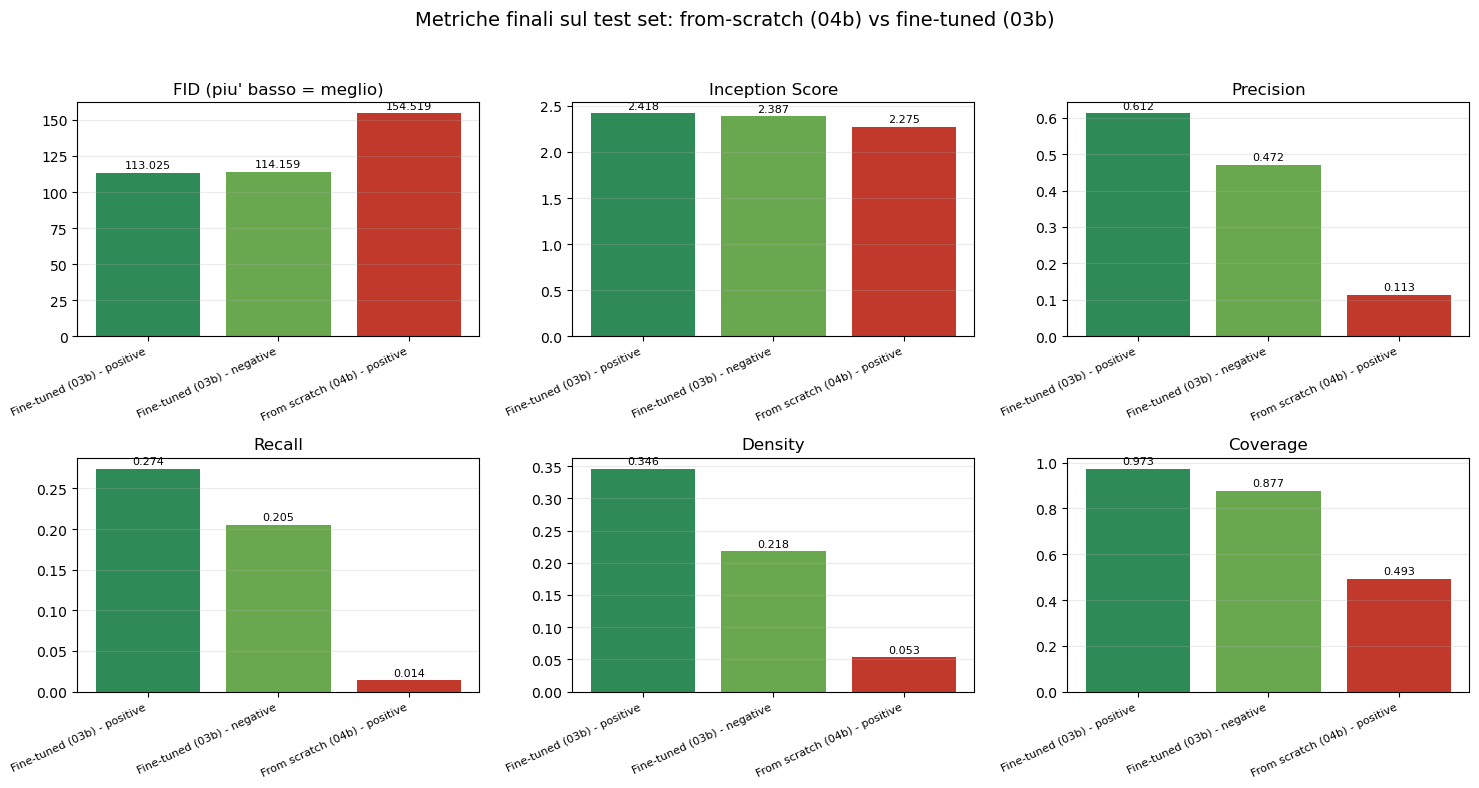

Salvato: /Users/alexandro/Desktop/MammoDiffusion/results/10_confronto_fromscratch_vs_finetuned/plots/final_test_metrics_comparison.png


In [26]:
metric_specs = [
    ("FID", "FID (piu' basso = meglio)"),
    ("IS_mean", "Inception Score"),
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("density", "Density"),
    ("coverage", "Coverage"),
]

df_final_metrics["serie"] = df_final_metrics["pipeline"] + " - " + df_final_metrics["class"]
colors = {
    "Fine-tuned (03b) - positive": "#2e8b57",
    "Fine-tuned (03b) - negative": "#6aa84f",
    "From scratch (04b) - positive": "#c0392b",
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (column, title) in zip(axes.ravel(), metric_specs):
    bars = ax.bar(
        df_final_metrics["serie"],
        df_final_metrics[column],
        color=[colors.get(serie, "#888888") for serie in df_final_metrics["serie"]],
    )
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)
    ax.set_title(title)
    plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Metriche finali sul test set: from-scratch (04b) vs fine-tuned (03b)", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.95))
output_path = RESULTS_PLOTS_DIR / "final_test_metrics_comparison.png"
fig.savefig(output_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Salvato:", output_path)
